In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Data Loading
images = np.load('../data/raw/galaxy10_images.npy')
labels = np.load('../data/raw/galaxy10_labels.npy')

CLASS_NAMES = [
    'Disturbed Galaxies',
    'Merging Galaxies', 
    'Round Smooth Galaxies',
    'In-between Smooth Galaxies',
    'Cigar Shaped Smooth Galaxies',
    'Barred Spiral Galaxies',
    'Unbarred Tight Spiral Galaxies',
    'Unbarred Loose Spiral Galaxies',
    'Edge-on Galaxies without Bulge',
    'Edge-on Galaxies with Bulge'
]

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Image dtype: {images.dtype}")
print(f"Pixel value range: {images.min()} – {images.max()}")
print()

counts = Counter(labels.tolist())
for i in range(10):
    print(f"  Class {i} ({CLASS_NAMES[i][:30]}): {counts[i]} images")

Images shape: (17736, 256, 256, 3)
Labels shape: (17736,)
Image dtype: uint8
Pixel value range: 0 – 255

  Class 0 (Disturbed Galaxies): 1081 images
  Class 1 (Merging Galaxies): 1853 images
  Class 2 (Round Smooth Galaxies): 2645 images
  Class 3 (In-between Smooth Galaxies): 2027 images
  Class 4 (Cigar Shaped Smooth Galaxies): 334 images
  Class 5 (Barred Spiral Galaxies): 2043 images
  Class 6 (Unbarred Tight Spiral Galaxies): 1829 images
  Class 7 (Unbarred Loose Spiral Galaxies): 2628 images
  Class 8 (Edge-on Galaxies without Bulge): 1423 images
  Class 9 (Edge-on Galaxies with Bulge): 1873 images


/var/folders/15/5hy9z95d3xq8fl7zjhghltg40000gn/T/ipykernel_74091/2162499742.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)


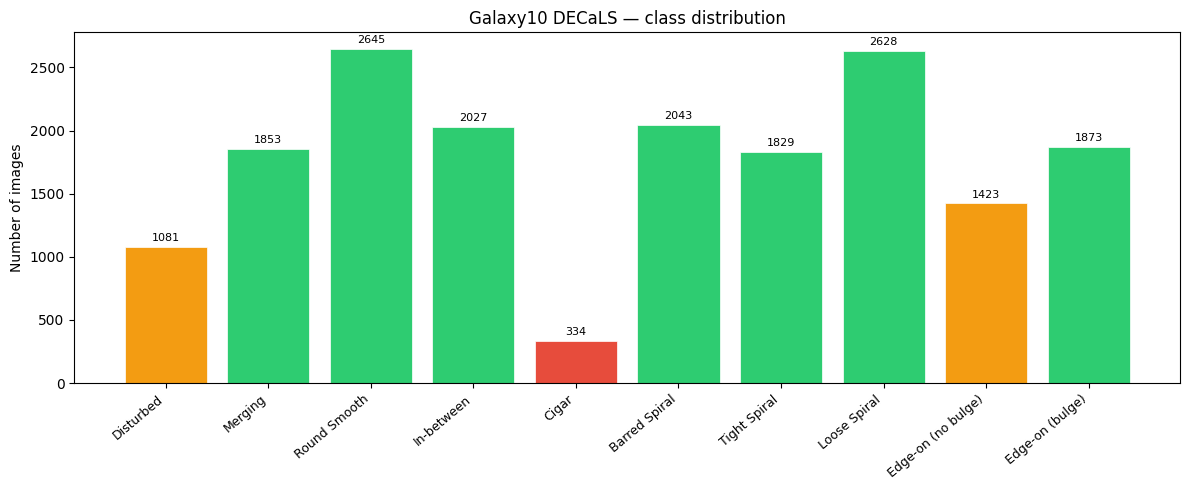

Saved to outputs/figures/


In [3]:
# Class distribution plot
fig, ax = plt.subplots(figsize=(12, 5))
short_names = [
    'Disturbed', 'Merging', 'Round Smooth', 'In-between',
    'Cigar', 'Barred Spiral', 'Tight Spiral',
    'Loose Spiral', 'Edge-on (no bulge)', 'Edge-on (bulge)'
]
count_vals = [counts[i] for i in range(10)]
colors = ['#e74c3c' if c < 500 else '#f39c12' if c < 1500 else '#2ecc71' for c in count_vals]

bars = ax.bar(short_names, count_vals, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Number of images')
ax.set_title('Galaxy10 DECaLS — class distribution')

for bar, val in zip(bars, count_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()
print("Saved to outputs/figures/")

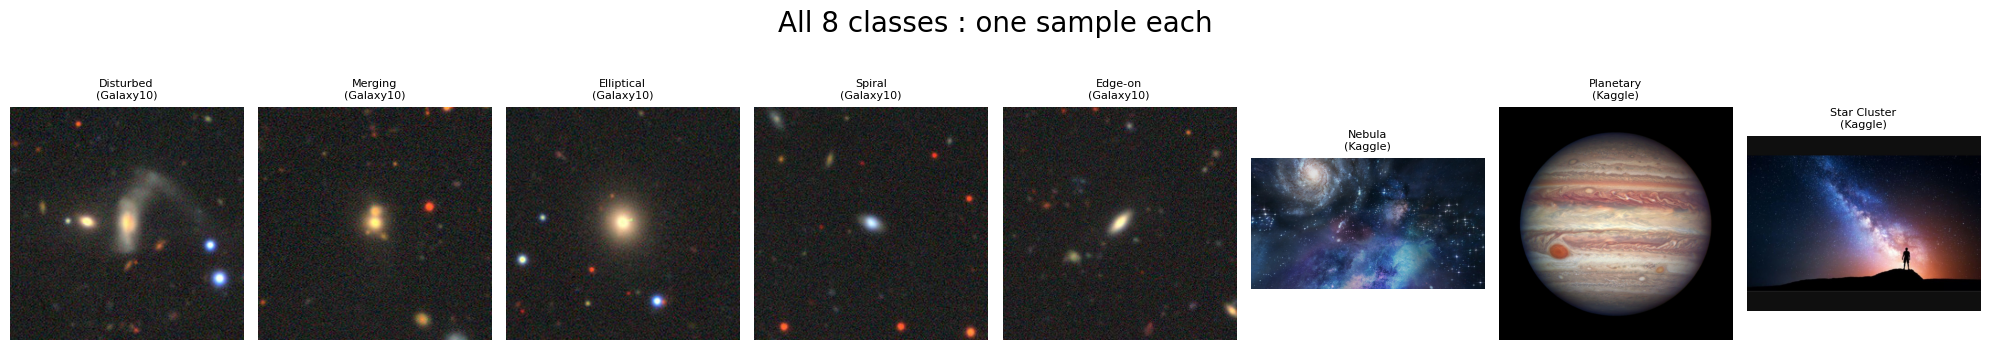

Saved to outputs/figures/


In [4]:
from PIL import Image
import os

# Galaxy10 samples (classes 0-4)
galaxy_short = ['Disturbed', 'Merging', 'Elliptical', 'Spiral', 'Edge-on']
kaggle_folders = {
    'Nebula':       '../data/kaggle_space/space images/nebula - Google Search',
    'Planetary':    '../data/kaggle_space/space images/planets - Google Search',
    'Star Cluster': '../data/kaggle_space/space images/stars - Google Search',
}

fig, axes = plt.subplots(1, 8, figsize=(20, 4))

# Classes 0-4: from numpy arrays
for i in range(5):
    idx = np.where(labels == i)[0][0]
    axes[i].imshow(images[idx])
    axes[i].set_title(f"{galaxy_short[i]}\n(Galaxy10)", fontsize=8)
    axes[i].axis('off')

# Classes 5-7: from Kaggle folders
for j, (name, folder) in enumerate(kaggle_folders.items()):
    fname = os.listdir(folder)[0]
    img = np.array(Image.open(os.path.join(folder, fname)).convert('RGB'))
    axes[5 + j].imshow(img)
    axes[5 + j].set_title(f"{name}\n(Kaggle)", fontsize=8)
    axes[5 + j].axis('off')

plt.suptitle('All 8 classes : one sample each', fontsize=20)
plt.tight_layout()
plt.savefig('../outputs/figures/class_samples_8class.png', dpi=150)
plt.show()
print("Saved to outputs/figures/")

In [5]:
import sys
sys.path.append('../')

from src.data.dataset import get_dataloaders, CLASS_NAMES

train_loader, val_loader, test_loader, class_names = get_dataloaders(
    images_path='../data/raw/galaxy10_images.npy',
    labels_path='../data/raw/galaxy10_labels.npy',
    kaggle_base_dir='../data/kaggle_space/space images',
    batch_size=32
)

images_batch, labels_batch = next(iter(train_loader))
print(f"Batch images shape: {images_batch.shape}")
print(f"Batch labels shape: {labels_batch.shape}")
print(f"Label values in batch: {labels_batch.unique()}")
print(f"Image tensor range: {images_batch.min():.2f} – {images_batch.max():.2f}")
print(f"\nClasses: {class_names}")

Loading Galaxy10..
  Galaxy10: 17736 images, 5 classes
Loading Kaggle space images...


/Users/rishikumar/astro_classifier/.venv/lib/python3.11/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  nebula - Google Search: 170 original images → augmenting to 800
  planets - Google Search: 176 original images → augmenting to 800
  stars - Google Search: 175 original images → augmenting to 800
  Kaggle total: 2400 images

Combined dataset: 20136 images, 8 classes
  [0] Disturbed/Irregular: 1081
  [1] Merging: 1853
  [2] Elliptical: 5006
  [3] Spiral: 6500
  [4] Edge-on: 3296
  [5] Nebula: 800
  [6] Planetary: 800
  [7] Star Cluster: 800

Split → Train: 14095 | Val: 3020 | Test: 3021
Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Label values in batch: tensor([0, 1, 2, 3, 4, 5, 6, 7])
Image tensor range: -2.12 – 2.64

Classes: ['Disturbed/Irregular', 'Merging', 'Elliptical', 'Spiral', 'Edge-on', 'Nebula', 'Planetary', 'Star Cluster']


In [ ]:
import sys
sys.path.append('../')

import torch
from src.models.model import build_model, get_model_info

# Phase 1 model
model = build_model(num_classes=7, freeze_backbone=True)

print("=== Phase 1 (backbone frozen) ===")
get_model_info(model)

device = torch.device('mps')
model = model.to(device)
dummy_input = torch.randn(4, 3, 224, 224).to(device)
output = model(dummy_input)
print(f"\nForward pass output shape: {output.shape}")
print(f"Expected: torch.Size([4, 5])")

# Phase 2
print("\n=== Phase 2 (all unfrozen) ===")
model2 = build_model(num_classes=7, freeze_backbone=False)
get_model_info(model2)

=== Phase 1 (backbone frozen) ===
Total parameters:     4,336,769
Trainable parameters: 329,221
Frozen parameters:    4,007,548

Forward pass output shape: torch.Size([4, 5])
Expected: torch.Size([4, 5])

=== Phase 2 (all unfrozen) ===
Total parameters:     4,337,540
Trainable parameters: 4,337,540
Frozen parameters:    0


In [ ]:
from src.models.trainer import train_one_epoch, evaluate
from src.models.model import build_model
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
device = torch.device('mps')

# Loading model with 8 classes
model = build_model(num_classes=7, freeze_backbone=True).to(device)

# One batch test

model.train()
images_batch, labels_batch = next(iter(train_loader))
images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

outputs = model(images_batch)
loss = criterion(outputs, labels_batch)
print(f"Loss on one batch: {loss.item():.4f}")
print(f"Output shape: {outputs.shape}")       # should be [32, 8]
print(f"Predictions: {outputs.argmax(dim=1)[:10]}")
print(f"Ground truth: {labels_batch[:10]}")
print("\nTrainer imports OK")

Loss on one batch: 2.0860
Output shape: torch.Size([32, 8])
Predictions: tensor([6, 7, 7, 2, 4, 2, 7, 1, 0, 0], device='mps:0')
Ground truth: tensor([2, 5, 0, 2, 1, 6, 4, 4, 6, 2], device='mps:0')

Trainer imports OK


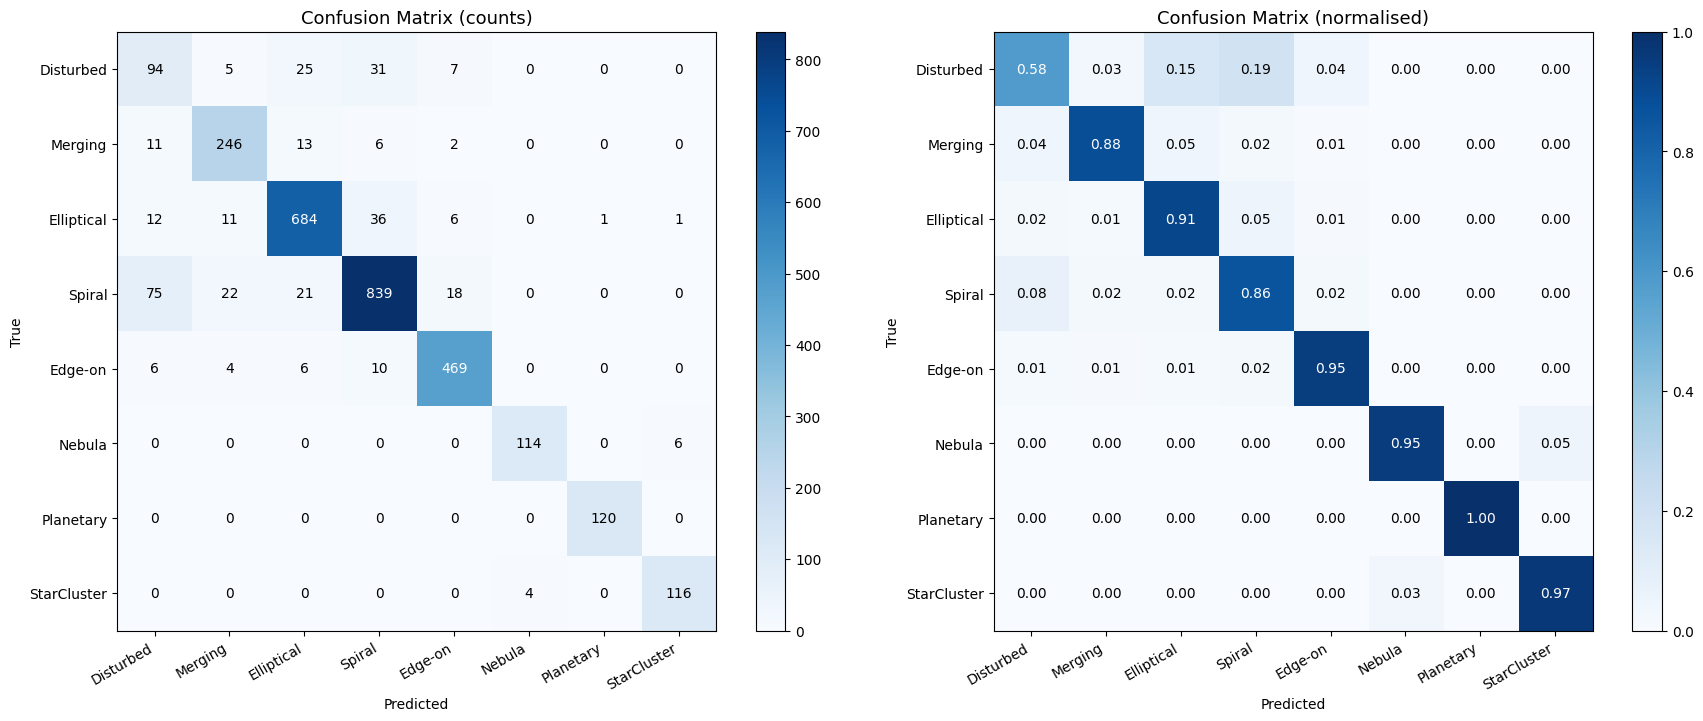

Saved to outputs/figures/


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Confusion matrix heatmap
cm = np.array([
    [ 94,   5,  25,  31,   7,   0,   0,   0],
    [ 11, 246,  13,   6,   2,   0,   0,   0],
    [ 12,  11, 684,  36,   6,   0,   1,   1],
    [ 75,  22,  21, 839,  18,   0,   0,   0],
    [  6,   4,   6,  10, 469,   0,   0,   0],
    [  0,   0,   0,   0,   0, 114,   0,   6],
    [  0,   0,   0,   0,   0,   0, 120,   0],
    [  0,   0,   0,   0,   0,   4,   0, 116],
])

class_names_short = ['Disturbed', 'Merging', 'Elliptical', 'Spiral', 'Edge-on', 'Nebula', 'Planetary', 'StarCluster']


# Normalise by row (true class)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
im1 = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Confusion Matrix (counts)', fontsize=13)
plt.colorbar(im1, ax=axes[0])
for i in range(8):
    for j in range(8):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=10)

# Normalised
im2 = axes[1].imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (normalised)', fontsize=13)
plt.colorbar(im2, ax=axes[1])
for i in range(8):
    for j in range(8):
        axes[1].text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=10)

for ax in axes:
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_xticklabels(class_names_short, rotation=30, ha='right')
    ax.set_yticklabels(class_names_short)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix.png', dpi=150)
plt.show()
print("Saved to outputs/figures/")

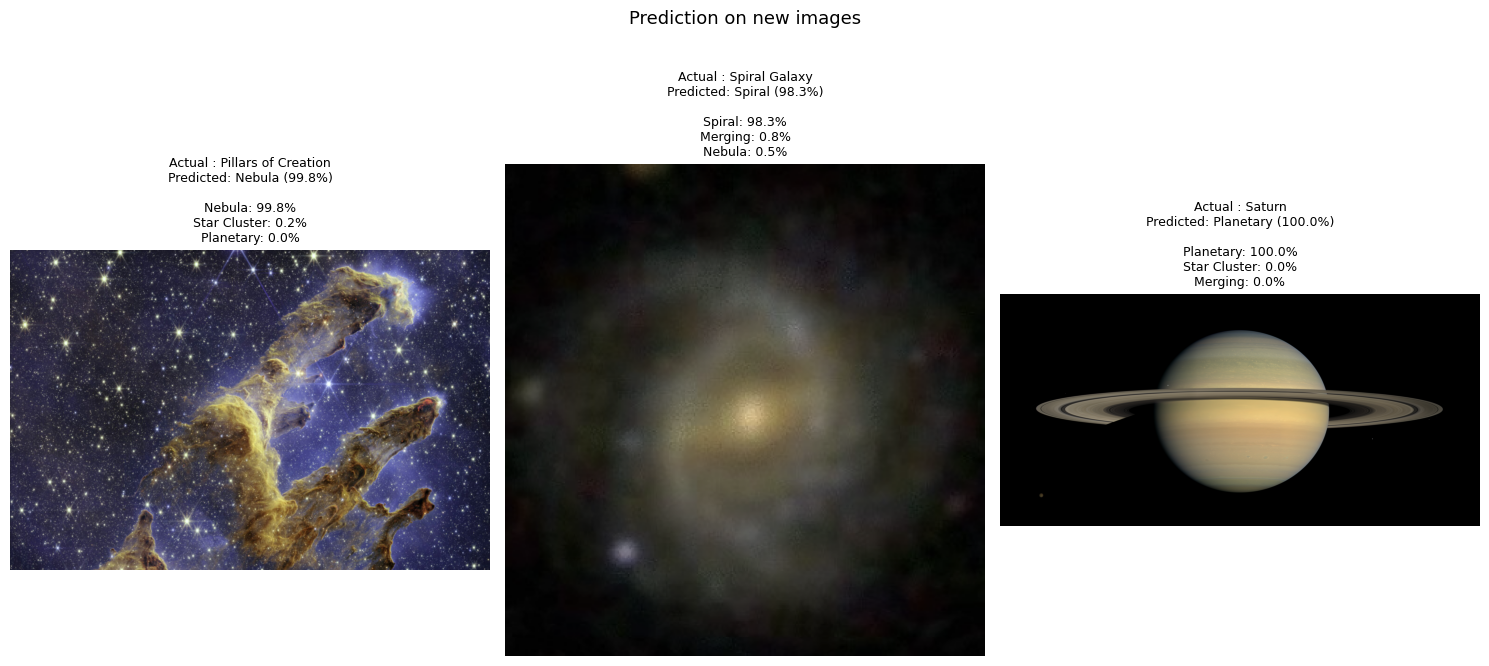

In [ ]:
import sys
sys.path.append('../')

import torch
import numpy as np
from PIL import Image
from src.models.model import build_model
from src.data.dataset import CLASS_NAMES, get_transforms
import matplotlib.pyplot as plt

device = torch.device('mps')

# Load model
model = build_model(num_classes=7, freeze_backbone=False)
model.load_state_dict(torch.load('../outputs/checkpoints/phase2_v2_best.pth', map_location=device))
model = model.to(device)
model.eval()

# Images to test
test_images = {
    'Actual : Pillars of Creation': '../test1.jpg',
    'Actual : Spiral Galaxy':    '../test2.jpg',
    'Actual : Saturn':              '../test3.jpg',
}

transform = get_transforms('val')

fig, axes = plt.subplots(1, 3, figsize=(15, 8))

for ax, (title, path) in zip(axes, test_images.items()):
    # Load and preprocess
    img = Image.open(path).convert('RGB')
    img_np = np.array(img, dtype=np.uint8)
    tensor = transform(img_np).unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = probs.argmax().item()
        confidence = probs[pred_idx].item()

    # Top 3 predictions
    top3 = probs.topk(3)
    top3_str = '\n'.join([
        f"{CLASS_NAMES[i]}: {p:.1%}"
        for p, i in zip(top3.values, top3.indices)
    ])

    ax.imshow(img)
    ax.set_title(f"{title}\nPredicted: { CLASS_NAMES[pred_idx]} ({confidence:.1%})\n\n{top3_str}", fontsize=9)
    ax.axis('off')

plt.suptitle('Prediction on new images', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/inference_test.png', dpi=150)
plt.show()

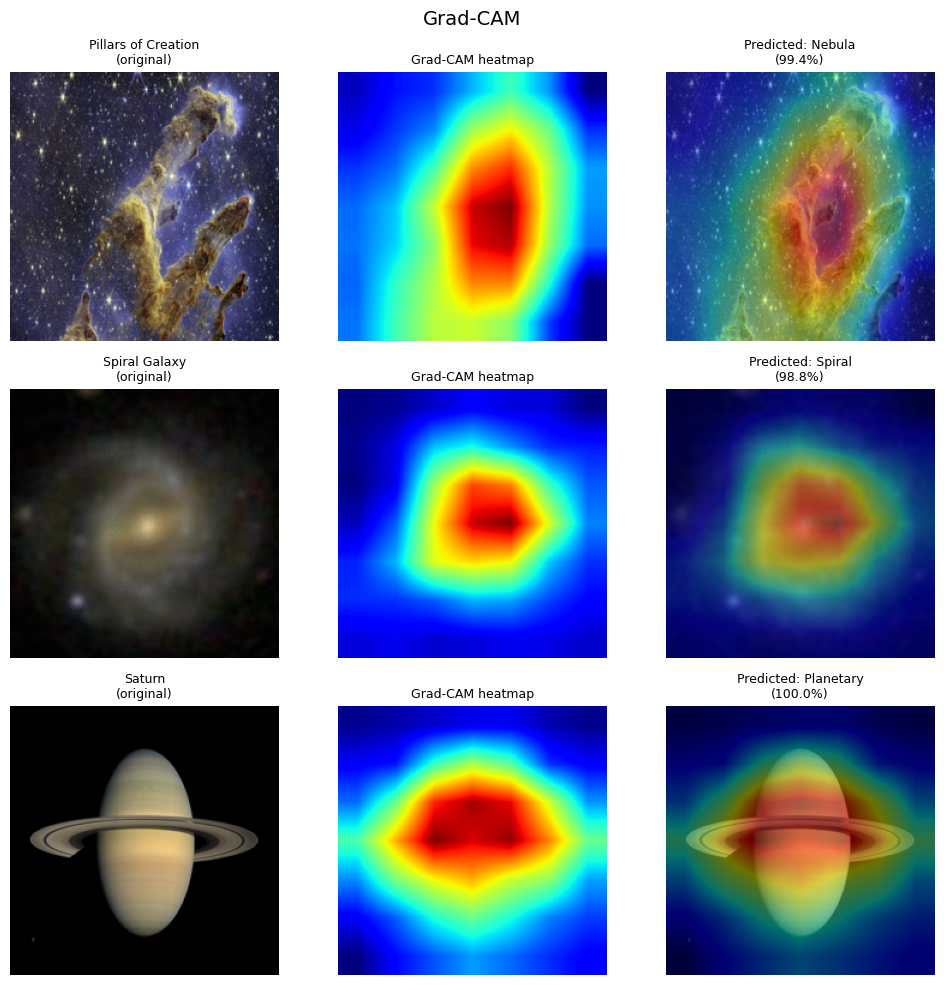

In [35]:
#GradCam!!!
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from src.data.dataset import get_transforms, CLASS_NAMES

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        # Register hooks on the target layer
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Pool gradients across channels
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        # Normalize to 0-1
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        # Resize to input size
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy(), class_idx


target_layer = model.features[-1][0]  # last conv block
gradcam = GradCAM(model, target_layer)

test_images = {
    'Pillars of Creation': '../test1.jpg',
    'Spiral Galaxy':       '../test2.jpg',
    'Saturn':              '../test3.jpg',
}

transform = get_transforms('val')
fig, axes = plt.subplots(3, 3, figsize=(10,10))

for row, (title, path) in enumerate(test_images.items()):
    img = Image.open(path).convert('RGB').resize((224, 224))
    img_np = np.array(img, dtype=np.uint8)
    tensor = transform(img_np).unsqueeze(0).to(device)

    cam, pred_idx = gradcam.generate(tensor)
    confidence = torch.softmax(model(tensor), dim=1)[0, pred_idx].item()

    # Col 0: original image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'{title}\n(original)', fontsize=9)
    axes[row, 0].axis('off')

    # Col 1: heatmap only
    axes[row, 1].imshow(cam, cmap='jet')
    axes[row, 1].set_title('Grad-CAM heatmap', fontsize=9)
    axes[row, 1].axis('off')

    # Col 2: overlay
    axes[row, 2].imshow(img)
    axes[row, 2].imshow(cam, cmap='jet', alpha=0.45)
    axes[row, 2].set_title(f'Predicted: {CLASS_NAMES[pred_idx]}\n({confidence:.1%})', fontsize=9)
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/gradcam/gradcam_test.png', dpi=150)
plt.show()

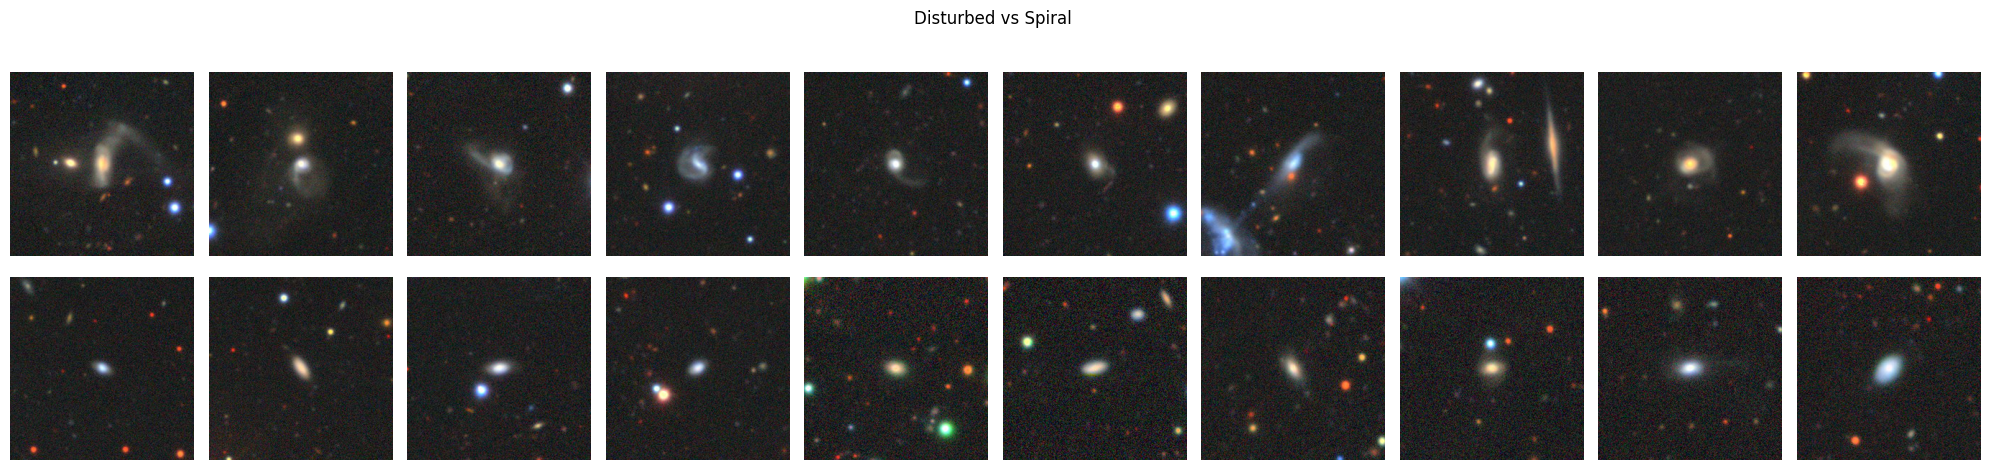

In [37]:
#  10 Disturbed samples + 10 Spiral samples side by side
fig, axes = plt.subplots(2, 10, figsize=(20, 5))

disturbed_idx = np.where(labels == 0)[0][:10]
spiral_idx = np.where(labels == 3)[0][:10]

for i, idx in enumerate(disturbed_idx):
    axes[0, i].imshow(images[idx])
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Disturbed', fontsize=10)

for i, idx in enumerate(spiral_idx):
    axes[1, i].imshow(images[idx])
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Spiral', fontsize=10)

plt.suptitle('Disturbed vs Spiral ', fontsize=12)
plt.tight_layout()
plt.show()

In [39]:
import pandas as pd

df = pd.read_csv('../data/gz2/gz2_hart16.csv', nrows=5)
print(df.shape)
print(df.columns.tolist())

(5, 231)
['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction', 't01_smooth_or_features_a03_star_or_a

In [40]:
import pandas as pd

df = pd.read_csv('../data/gz2/gz2_hart16.csv')
print(f"Total galaxies: {len(df)}")

disturbed = df[df['t08_odd_feature_a21_disturbed_debiased'] > 0.5]
print(f"High confidence disturbed (>0.5): {len(disturbed)}")

irregular = df[df['t08_odd_feature_a22_irregular_debiased'] > 0.5]
print(f"High confidence irregular (>0.5): {len(irregular)}")

disturbed_or_irregular = df[
    (df['t08_odd_feature_a21_disturbed_debiased'] > 0.5) |
    (df['t08_odd_feature_a22_irregular_debiased'] > 0.5)
]
print(f"Disturbed OR irregular (>0.5): {len(disturbed_or_irregular)}")

disturbed_or_irregular_low = df[
    (df['t08_odd_feature_a21_disturbed_debiased'] > 0.3) |
    (df['t08_odd_feature_a22_irregular_debiased'] > 0.3)
]
print(f"Disturbed OR irregular (>0.3): {len(disturbed_or_irregular_low)}")

Total galaxies: 239695
High confidence disturbed (>0.5): 27755
High confidence irregular (>0.5): 15874
Disturbed OR irregular (>0.5): 43629
Disturbed OR irregular (>0.3): 82249


In [41]:
import pandas as pd

df = pd.read_csv('../data/gz2/gz2_hart16.csv')
mapping = pd.read_csv('../data/gz2/gz2_filename_mapping.csv')

print(f"Mapping shape: {mapping.shape}")
print(mapping.head())

# Cross-reference
disturbed_or_irregular = df[
    (df['t08_odd_feature_a21_disturbed_debiased'] > 0.5) |
    (df['t08_odd_feature_a22_irregular_debiased'] > 0.5)
]

merged = disturbed_or_irregular.merge(mapping, left_on='dr7objid', right_on='objid', how='inner')
print(f"\nDisturbed/Irregular with images: {len(merged)}")
print(merged[['dr7objid', 'asset_id']].head(10))


Mapping shape: (355990, 3)
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3
3  587722981741363323  original         4
4  587722981741559888  original         5

Disturbed/Irregular with images: 43629
             dr7objid  asset_id
0  587741723357282317    158501
1  588009365861498889    192974
2  587742610812698666    177979
3  587729653421113535     36981
4  587741532236349588    151792
5  587739719763558489    137506
6  588013382727041059    203825
7  587729777453367603     39426
8  587736542027645130     91314
9  587725472807518350      7515


In [42]:
# Get top 2000 most confidently disturbed/irregular
merged['max_disturbed'] = merged[
    ['t08_odd_feature_a21_disturbed_debiased', 
     't08_odd_feature_a22_irregular_debiased']
].max(axis=1)

top2000 = merged.nlargest(2000, 'max_disturbed')[['dr7objid', 'asset_id', 'max_disturbed']]
print(top2000.head(10))
print(f"\nMin confidence in top 2000: {top2000['max_disturbed'].min():.3f}")

# Saving asset_ids for downloading
top2000['asset_id'].to_csv('../data/gz2/disturbed_asset_ids.txt', index=False, header=False)
print("Saved asset IDs to data/gz2/disturbed_asset_ids.txt")


              dr7objid  asset_id  max_disturbed
1   588009365861498889    192974            1.0
3   587729653421113535     36981            1.0
5   587739719763558489    137506            1.0
6   588013382727041059    203825            1.0
16  588013383283376276    204481            1.0
31  587725491062898768      7946            1.0
41  587736976349462537    103583            1.0
42  587733603180216440     69880            1.0
47  587729386607935629     34313            1.0
56  587733609093136687    253993            1.0

Min confidence in top 2000: 1.000
Saved asset IDs to data/gz2/disturbed_asset_ids.txt


/var/folders/15/5hy9z95d3xq8fl7zjhghltg40000gn/T/ipykernel_74091/2845458154.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged['max_disturbed'] = merged[


In [ ]:
import zipfile
import os
import pandas as pd

# Loading the asset IDs we want
asset_ids = pd.read_csv('../data/gz2/disturbed_asset_ids.txt', header=None)[0].tolist()
asset_ids = [str(a) for a in asset_ids]

print(f"Looking for {len(asset_ids)} images...")

# Output folder
out_dir = '../data/gz2/disturbed_images'
os.makedirs(out_dir, exist_ok=True)

zip_path = '../data/gz2/images_gz2.zip'

extracted = 0
not_found = 0

with zipfile.ZipFile(zip_path, 'r') as zf:
    all_files = set(zf.namelist())
    
    for asset_id in asset_ids:
        fname = f'images_gz2/images/{asset_id}.jpg'
        if fname in all_files:
            # Extract just this one file
            zf.extract(fname, '../data/gz2/temp/')
            # Move to clean output folder
            src = f'../data/gz2/temp/{fname}'
            dst = f'{out_dir}/{asset_id}.jpg'
            os.rename(src, dst)
            extracted += 1
        else:
            not_found += 1
    
    if extracted % 100 == 0:
        print(f"Extracted {extracted}...")

print(f"\nDone! Extracted: {extracted} | Not found: {not_found}")
print(f"Images saved to {out_dir}")

In [44]:
import zipfile
import os
import pandas as pd

# Load the asset IDs we want
asset_ids = pd.read_csv('../data/gz2/disturbed_asset_ids.txt', header=None)[0].tolist()
asset_ids = [str(a) for a in asset_ids]

print(f"Looking for {len(asset_ids)} images...")

# Output folder
out_dir = '../data/gz2/disturbed_images'
os.makedirs(out_dir, exist_ok=True)

zip_path = '../data/gz2/galaxy-zoo-2-images.zip'

extracted = 0
not_found = 0

with zipfile.ZipFile(zip_path, 'r') as zf:
    all_files = set(zf.namelist())
    
    for asset_id in asset_ids:
        fname = f'images_gz2/images/{asset_id}.jpg'
        if fname in all_files:
            # Extract just this one file
            zf.extract(fname, '../data/gz2/temp/')
            # Move to clean output folder
            src = f'../data/gz2/temp/{fname}'
            dst = f'{out_dir}/{asset_id}.jpg'
            os.rename(src, dst)
            extracted += 1
        else:
            not_found += 1
    
    if extracted % 100 == 0:
        print(f"Extracted {extracted}...")

print(f"\nDone! Extracted: {extracted} | Not found: {not_found}")
print(f"Images saved to {out_dir}")

Looking for 2000 images...

Done! Extracted: 1999 | Not found: 1
Images saved to ../data/gz2/disturbed_images


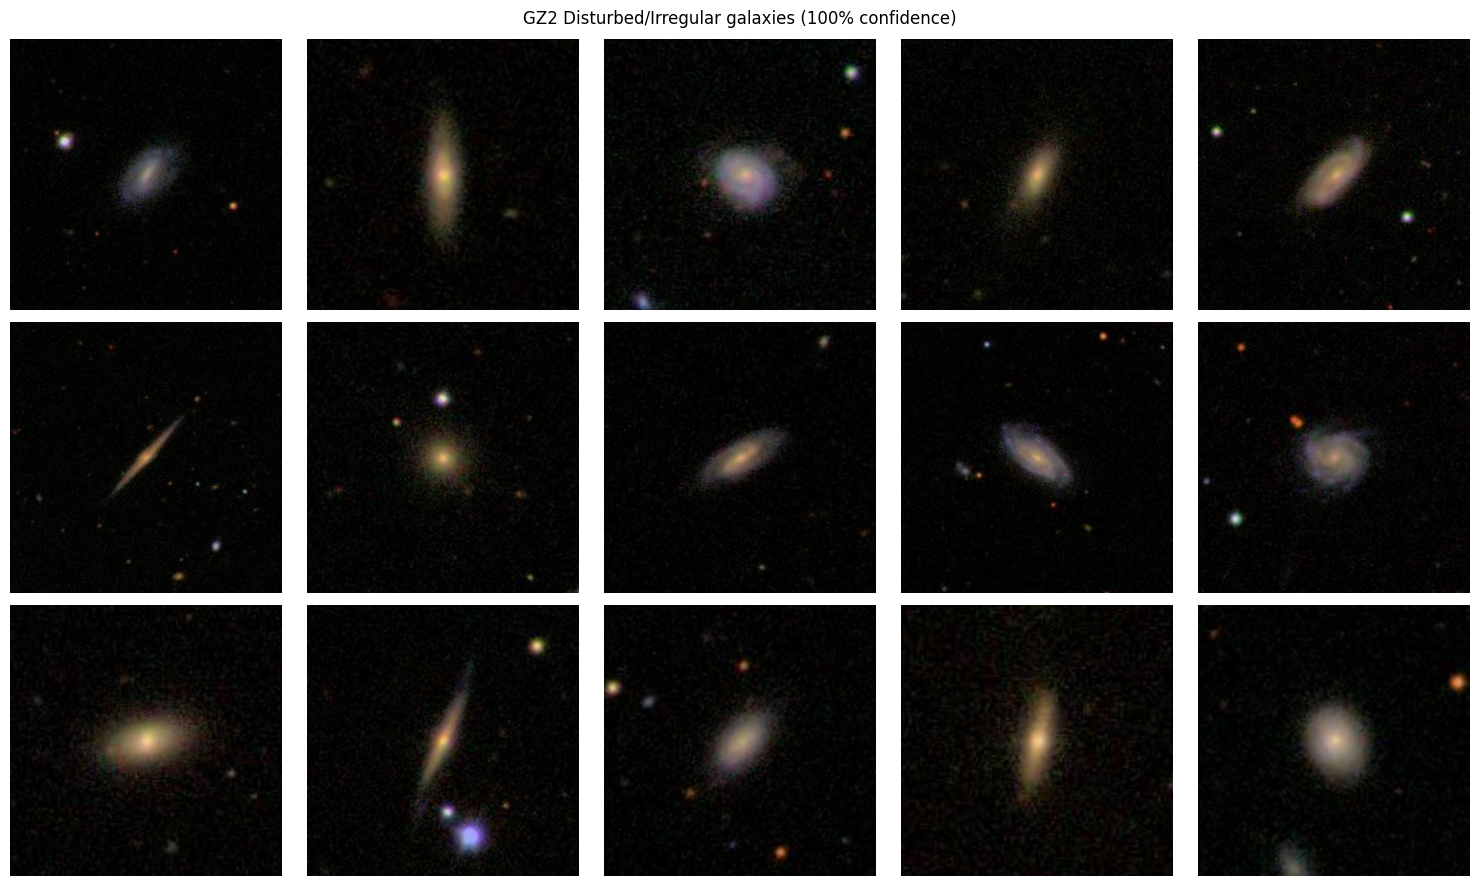

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

img_dir = '../data/gz2/disturbed_images'
files = os.listdir(img_dir)[:15]

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for ax, fname in zip(axes.flat, files):
    img = Image.open(os.path.join(img_dir, fname)).convert('RGB')
    ax.imshow(np.array(img))
    ax.axis('off')

plt.suptitle('GZ2 Disturbed/Irregular galaxies (100% confidence)', fontsize=12)
plt.tight_layout()
plt.show()


In [46]:
#I am deciding to drop the disturbed label as it genuinely looks like other ones. I will just focus on rest 7